# Wrinkle Segmentation with SegFormer

In [22]:
import gc
import random
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageFilter
from sklearn.model_selection import train_test_split
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import torchvision.transforms.functional as TF
from torchvision.transforms import InterpolationMode

from transformers import SegformerForSemanticSegmentation

## Configuration

In [23]:
SEED = 42
IMG_SIZE = 1024
BATCH_SIZE = 2
NUM_EPOCHS = 45
NUM_WORKERS = 0

MODEL_NAME = "nvidia/segformer-b2-finetuned-ade-512-512"
CHECKPOINT_PATH = "best_segformer_b2_wrinkles.pt"


# Dataset paths
MASK_DIR = Path("/kaggle/input/datasets/karmagames/wrinkles-dataset/manual_wrinkle_masks/manual_wrinkle_masks")


# For a baseline experiment, which involves only augmentations
IMG_DIR = Path("/kaggle/input/datasets/karmagames/wrinkles-dataset/images_wrinkles/images_wrinkles")

# # For a ROI experiment, which involves extraction of facial ROI region
# IMG_DIR = Path("/kaggle/input/datasets/karmagames/wrinkles-dataset/clean_roi/clean_roi")

# # For a CLAHE & ITA experiment, which involves CLAHE transform, conditioned on ITA
# IMG_DIR = Path("/kaggle/input/datasets/karmagames/wrinkles-dataset/images_wrinkles_preprocess/images_wrinkles_preprocess")


IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
IMAGENET_STD = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)
torch.backends.cudnn.benchmark = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


## Augmentations and Dataset

In [24]:
class RandomGamma:
    def __init__(self, gamma_range=(0.9, 1.1), p=0.3):
        self.gamma_range = gamma_range
        self.p = p

    def __call__(self, img):
        if random.random() > self.p:
            return img
        gamma = random.uniform(*self.gamma_range)
        return TF.adjust_gamma(img, gamma)


class RandomGaussianBlur:
    def __init__(self, radius_range=(0.1, 0.6), p=0.2):
        self.radius_range = radius_range
        self.p = p

    def __call__(self, img):
        if random.random() > self.p:
            return img
        radius = random.uniform(*self.radius_range)
        return img.filter(ImageFilter.GaussianBlur(radius))


class CLAHELabTransform:
    def __init__(self, clip_limit=1, tile_grid_size=(8, 8), p=0.25):
        self.clip_limit = clip_limit
        self.tile_grid_size = tile_grid_size
        self.p = p

    def __call__(self, img):
        if random.random() > self.p:
            return img

        img_np = np.array(img)
        lab = cv2.cvtColor(img_np, cv2.COLOR_RGB2LAB)
        l, a, b = cv2.split(lab)

        clahe = cv2.createCLAHE(
            clipLimit=self.clip_limit,
            tileGridSize=self.tile_grid_size
        )
        l = clahe.apply(l)

        lab = cv2.merge([l, a, b])
        out = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)
        return Image.fromarray(out)


class WrinkleSegDataset(Dataset):
    def __init__(self, pairs, img_size=1024, train=False):
        self.pairs = pairs
        self.img_size = img_size
        self.train = train

        self.normalize = transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )

        self.color_aug = transforms.Compose([
            transforms.ColorJitter(
                brightness=0.20,
                contrast=0.20,
                saturation=0.08,
                hue=0.015
            ),
            RandomGamma(gamma_range=(0.80, 1.25), p=0.50),
            RandomGaussianBlur(radius_range=(0.1, 0.8), p=0.20),
        ])

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        img_path, mask_path = self.pairs[idx]

        img = Image.open(img_path).convert("RGB")
        mask = Image.open(mask_path).convert("L")

        img = TF.resize(img, [self.img_size, self.img_size], interpolation=InterpolationMode.BILINEAR)
        mask = TF.resize(mask, [self.img_size, self.img_size], interpolation=InterpolationMode.NEAREST)

        if self.train:
            if random.random() < 0.5:
                img = TF.hflip(img)
                mask = TF.hflip(mask)

            if random.random() < 0.15:
                img = TF.vflip(img)
                mask = TF.vflip(mask)

            angle = random.uniform(-10, 10)
            img = TF.rotate(img, angle, interpolation=InterpolationMode.BILINEAR)
            mask = TF.rotate(mask, angle, interpolation=InterpolationMode.NEAREST)

            img = self.color_aug(img)

        x = TF.to_tensor(img)
        x = self.normalize(x)

        y = TF.to_tensor(mask)
        y = (y > 0.5).float()

        return x, y

## Utility Visualization Functions

In [25]:
def denormalize_image(x, mean=IMAGENET_MEAN, std=IMAGENET_STD):
    x = x.detach().cpu()
    x = x * mean.new_tensor(std) + mean
    return torch.clamp(x, 0, 1)


def tensor_to_image(x):
    return denormalize_image(x).permute(1, 2, 0).numpy()


def show_batch_with_masks(loader):
    imgs, masks = next(iter(loader))
    imgs = imgs.cpu()
    masks = masks.cpu()

    batch_size = imgs.shape[0]
    fig, axes = plt.subplots(2, batch_size, figsize=(3 * batch_size, 6))

    if batch_size == 1:
        axes = np.expand_dims(axes, axis=1)

    for i in range(batch_size):
        img = tensor_to_image(imgs[i])
        mask = masks[i, 0].numpy()

        axes[0, i].imshow(img)
        axes[0, i].axis("off")

        axes[1, i].imshow(mask, cmap="gray")
        axes[1, i].axis("off")

    axes[0, batch_size // 2].set_title("Images")
    axes[1, batch_size // 2].set_title("Masks")

    plt.tight_layout()
    plt.show()


def compute_metrics_single(pred, gt, eps=1e-8):
    pred = pred.astype(np.float32)
    gt = gt.astype(np.float32)

    intersection = (pred * gt).sum()
    union = pred.sum() + gt.sum() - intersection

    iou = (intersection + eps) / (union + eps)
    dice = (2 * intersection + eps) / (pred.sum() + gt.sum() + eps)
    return dice, iou


def make_error_overlay(img, pred, gt, alpha=0.45):
    pred = pred.astype(bool)
    gt = gt.astype(bool)

    tp = pred & gt
    fp = pred & (~gt)
    fn = (~pred) & gt

    overlay = img.copy()
    overlay[tp] = (1 - alpha) * overlay[tp] + alpha * np.array([0.0, 1.0, 0.0])
    overlay[fp] = (1 - alpha) * overlay[fp] + alpha * np.array([1.0, 0.0, 0.0])
    overlay[fn] = (1 - alpha) * overlay[fn] + alpha * np.array([0.0, 0.0, 1.0])

    return np.clip(overlay, 0, 1)


def visualize_predictions_grid(imgs, masks, preds, n=4):
    n = min(n, len(imgs))
    fig, axes = plt.subplots(n, 4, figsize=(18, 4 * n))

    if n == 1:
        axes = np.expand_dims(axes, axis=0)

    for i in range(n):
        img = tensor_to_image(imgs[i])
        gt = masks[i, 0].numpy()
        pred = preds[i, 0].numpy()

        dice, iou = compute_metrics_single(pred, gt)
        overlay = make_error_overlay(img, pred, gt, alpha=0.45)

        axes[i, 0].imshow(img)
        axes[i, 0].set_title("Image")
        axes[i, 0].axis("off")

        axes[i, 1].imshow(gt, cmap="gray")
        axes[i, 1].set_title("Ground Truth")
        axes[i, 1].axis("off")

        axes[i, 2].imshow(pred, cmap="gray")
        axes[i, 2].set_title(f"Prediction | Dice={dice:.3f}  IoU={iou:.3f}")
        axes[i, 2].axis("off")

        axes[i, 3].imshow(overlay)
        axes[i, 3].set_title("Overlay | Green=TP  Red=FP  Blue=FN")
        axes[i, 3].axis("off")

    plt.tight_layout()
    plt.show()


def plot_history(history):
    plt.figure(figsize=(8, 5))
    plt.plot(history["epoch"], history["train_loss"], label="train loss")
    plt.plot(history["epoch"], history["val_loss"], label="val loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(history["epoch"], history["train_dice"], label="train Dice")
    plt.plot(history["epoch"], history["val_dice"], label="val Dice")
    plt.xlabel("Epoch")
    plt.ylabel("Dice")
    plt.legend()
    plt.grid(True)
    plt.show()

## Prepare Data

In [27]:
def collect_image_mask_pairs(image_dir, mask_dir):
    image_paths = sorted(image_dir.glob("*.png"))
    pairs = []

    for img_path in image_paths:
        mask_path = mask_dir / img_path.name
        if mask_path.exists():
            pairs.append((img_path, mask_path))
        else:
            print(f"Mask not found for {img_path.name}")

    return pairs


pairs = collect_image_mask_pairs(IMG_DIR, MASK_DIR)
print(f"Recovered {len(pairs)} pairs successfully.")
pairs[:3]

Recovered 1000 pairs successfully.


[(PosixPath('/kaggle/input/datasets/karmagames/wrinkles-dataset/images_wrinkles/images_wrinkles/00001.png'),
  PosixPath('/kaggle/input/datasets/karmagames/wrinkles-dataset/manual_wrinkle_masks/manual_wrinkle_masks/00001.png')),
 (PosixPath('/kaggle/input/datasets/karmagames/wrinkles-dataset/images_wrinkles/images_wrinkles/00011.png'),
  PosixPath('/kaggle/input/datasets/karmagames/wrinkles-dataset/manual_wrinkle_masks/manual_wrinkle_masks/00011.png')),
 (PosixPath('/kaggle/input/datasets/karmagames/wrinkles-dataset/images_wrinkles/images_wrinkles/00016.png'),
  PosixPath('/kaggle/input/datasets/karmagames/wrinkles-dataset/manual_wrinkle_masks/manual_wrinkle_masks/00016.png'))]

train/val/test: 800 100 100


/tmp/ipykernel_57/318470792.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than tensor.new_tensor(sourceTensor).
  x = x * mean.new_tensor(std) + mean


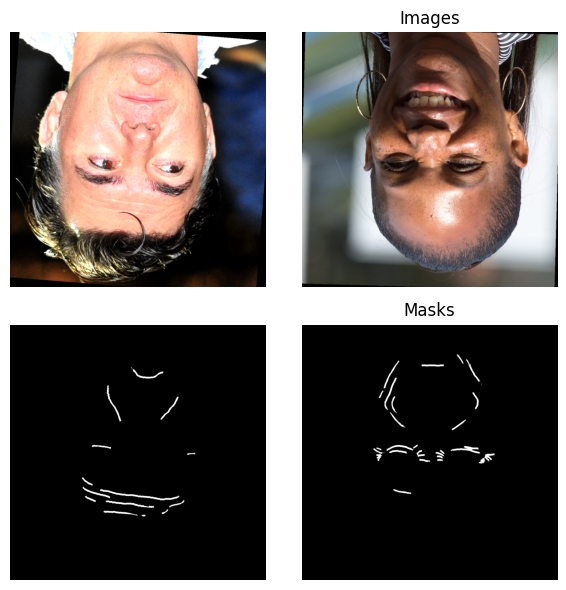

In [28]:
train_pairs, temp_pairs = train_test_split(
    pairs,
    test_size=0.2,
    random_state=SEED,
    shuffle=True
)

val_pairs, test_pairs = train_test_split(
    temp_pairs,
    test_size=0.5,
    random_state=SEED,
    shuffle=True
)

train_ds = WrinkleSegDataset(train_pairs, img_size=IMG_SIZE, train=True)
val_ds = WrinkleSegDataset(val_pairs, img_size=IMG_SIZE, train=False)
test_ds = WrinkleSegDataset(test_pairs, img_size=IMG_SIZE, train=False)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True,
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
)

test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
)

print("train/val/test:", len(train_ds), len(val_ds), len(test_ds))
show_batch_with_masks(train_loader)

## Model

In [29]:
class SegFormerBinary(nn.Module):
    def __init__(self, model_name=MODEL_NAME, dropout=0.1):
        super().__init__()

        self.model = SegformerForSemanticSegmentation.from_pretrained(
            model_name,
            num_labels=1,
            ignore_mismatched_sizes=True,
        )

        if hasattr(self.model.decode_head, "dropout"):
            self.model.decode_head.dropout.p = dropout

    def forward(self, x):
        out = self.model(pixel_values=x)
        logits = out.logits

        logits = F.interpolate(
            logits,
            size=x.shape[-2:],
            mode="bilinear",
            align_corners=False,
        )
        return logits


model = SegFormerBinary(model_name=MODEL_NAME, dropout=0.1).to(device)
print("Model initialized:", MODEL_NAME)

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/110M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/380 [00:00<?, ?it/s]

SegformerForSemanticSegmentation LOAD REPORT from: nvidia/segformer-b2-finetuned-ade-512-512
Key                           | Status   |                                                                                                   
------------------------------+----------+---------------------------------------------------------------------------------------------------
decode_head.classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([150, 768, 1, 1]) vs model:torch.Size([1, 768, 1, 1])
decode_head.classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([150]) vs model:torch.Size([1])                      

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


Model initialized: nvidia/segformer-b2-finetuned-ade-512-512


model.safetensors:   0%|          | 0.00/110M [00:00<?, ?B/s]

## Losses and Metrics

In [ ]:
@torch.no_grad()
def dice_coef_from_logits(logits, targets, eps=1e-7, threshold=0.5):
    preds = (torch.sigmoid(logits) > threshold).float()
    targets = targets.float()

    preds = preds.flatten(1)
    targets = targets.flatten(1)

    intersection = (preds * targets).sum(dim=1)
    denominator = preds.sum(dim=1) + targets.sum(dim=1)

    return ((2 * intersection + eps) / (denominator + eps)).mean()


@torch.no_grad()
def iou_from_logits(logits, targets, eps=1e-7, threshold=0.5):
    preds = (torch.sigmoid(logits) > threshold).float()
    targets = targets.float()

    preds = preds.flatten(1)
    targets = targets.flatten(1)

    intersection = (preds * targets).sum(dim=1)
    union = preds.sum(dim=1) + targets.sum(dim=1) - intersection

    return ((intersection + eps) / (union + eps)).mean()


class SoftDiceLoss(nn.Module):
    def __init__(self, eps=1e-7):
        super().__init__()
        self.eps = eps

    def forward(self, logits, targets):
        probs = torch.sigmoid(logits)
        targets = targets.float()

        probs = probs.flatten(1)
        targets = targets.flatten(1)

        intersection = (probs * targets).sum(dim=1)
        denominator = probs.sum(dim=1) + targets.sum(dim=1)

        dice = (2 * intersection + self.eps) / (denominator + self.eps)
        return 1 - dice.mean()


class TverskyLoss(nn.Module):
    def __init__(self, alpha=0.3, beta=0.7, eps=1e-7):
        super().__init__()
        self.alpha = alpha
        self.beta = beta
        self.eps = eps

    def forward(self, logits, targets):
        probs = torch.sigmoid(logits)
        targets = targets.float()

        probs = probs.flatten(1)
        targets = targets.flatten(1)

        tp = (probs * targets).sum(dim=1)
        fp = (probs * (1 - targets)).sum(dim=1)
        fn = ((1 - probs) * targets).sum(dim=1)

        tversky = (tp + self.eps) / (tp + self.alpha * fp + self.beta * fn + self.eps)
        return 1 - tversky.mean()


bce_loss = nn.BCEWithLogitsLoss()
dice_loss = SoftDiceLoss()
tversky_loss = TverskyLoss(alpha=0.3, beta=0.7)


def loss_fn(logits, targets):
    return (
        0.45 * bce_loss(logits, targets.float()) +
        0.30 * dice_loss(logits, targets) +
        0.25 * tversky_loss(logits, targets)
    )

## Training and Evaluation Functions

In [ ]:
def train_one_epoch(
    model,
    loader,
    optimizer,
    device,
    epoch,
    epochs,
    scaler=None,
    grad_clip=1.0,
    accum_steps=4,
):
    model.train()

    total_loss = 0.0
    total_dice = 0.0
    n = 0

    optimizer.zero_grad(set_to_none=True)
    pbar = tqdm(loader, desc=f"epoch {epoch + 1}/{epochs}", leave=False)

    amp_enabled = scaler is not None and device.type == "cuda"

    for step, (imgs, masks) in enumerate(pbar):
        imgs = imgs.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)

        if amp_enabled:
            with torch.autocast(device_type=device.type, dtype=torch.float16):
                logits = model(imgs)
                loss = loss_fn(logits, masks)

            scaler.scale(loss / accum_steps).backward()

            if (step + 1) % accum_steps == 0 or (step + 1) == len(loader):
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
                scaler.step(optimizer)
                scaler.update()
                optimizer.zero_grad(set_to_none=True)
        else:
            logits = model(imgs)
            loss = loss_fn(logits, masks)
            (loss / accum_steps).backward()

            if (step + 1) % accum_steps == 0 or (step + 1) == len(loader):
                torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
                optimizer.step()
                optimizer.zero_grad(set_to_none=True)

        batch_size = imgs.size(0)

        with torch.no_grad():
            dice = dice_coef_from_logits(logits, masks).item()

        total_loss += loss.item() * batch_size
        total_dice += dice * batch_size
        n += batch_size

        pbar.set_postfix({
            "loss": f"{total_loss / n:.4f}",
            "dice": f"{total_dice / n:.4f}",
        })

        del imgs, masks, logits, loss

    return {
        "loss": total_loss / n,
        "dice": total_dice / n,
    }


@torch.no_grad()
def evaluate(model, loader, device, use_amp=True):
    model.eval()

    total_loss = 0.0
    total_dice = 0.0
    total_iou = 0.0
    n = 0

    amp_enabled = use_amp and device.type == "cuda"

    for imgs, masks in loader:
        imgs = imgs.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)

        with torch.autocast(device_type=device.type, dtype=torch.float16, enabled=amp_enabled):
            logits = model(imgs)
            loss = loss_fn(logits, masks)

        batch_size = imgs.size(0)
        total_loss += loss.item() * batch_size
        total_dice += dice_coef_from_logits(logits, masks).item() * batch_size
        total_iou += iou_from_logits(logits, masks).item() * batch_size
        n += batch_size

        del imgs, masks, logits, loss

    return {
        "loss": total_loss / n,
        "dice": total_dice / n,
        "iou": total_iou / n,
    }


@torch.no_grad()
def evaluate_segmentation_metrics(model, loader, device, threshold=0.5, eps=1e-8):
    model.eval()

    total_tp = 0.0
    total_fp = 0.0
    total_fn = 0.0
    total_tn = 0.0

    for imgs, masks in loader:
        imgs = imgs.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True).float()

        logits = model(imgs)
        probs = torch.sigmoid(logits)
        preds = (probs > threshold).float()

        total_tp += (preds * masks).sum().item()
        total_fp += (preds * (1 - masks)).sum().item()
        total_fn += ((1 - preds) * masks).sum().item()
        total_tn += ((1 - preds) * (1 - masks)).sum().item()

    precision = total_tp / (total_tp + total_fp + eps)
    recall = total_tp / (total_tp + total_fn + eps)
    iou = total_tp / (total_tp + total_fp + total_fn + eps)
    dice = (2 * total_tp) / (2 * total_tp + total_fp + total_fn + eps)
    accuracy = (total_tp + total_tn) / (total_tp + total_tn + total_fp + total_fn + eps)

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "iou": iou,
        "dice": dice,
    }


@torch.no_grad()
def get_predictions(model, loader, device, threshold=0.5):
    model.eval()
    imgs, masks = next(iter(loader))

    imgs = imgs.to(device, non_blocking=True)
    masks = masks.to(device, non_blocking=True).float()

    logits = model(imgs)
    probs = torch.sigmoid(logits)
    preds = (probs > threshold).float()

    return imgs.cpu(), masks.cpu(), probs.cpu(), preds.cpu()

## Optimizer and Scheduler

In [ ]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4,
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer,
    T_0=8,
    T_mult=1,
    eta_min=1e-6,
)

use_amp = torch.cuda.is_available()
scaler = torch.amp.GradScaler("cuda") if use_amp else None

gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

## Training

In [ ]:
best_dice = -1.0

history = {
    "epoch": [],
    "train_loss": [],
    "train_dice": [],
    "val_loss": [],
    "val_dice": [],
    "val_iou": [],
    "lr": [],
}

for epoch in range(NUM_EPOCHS):
    train_metrics = train_one_epoch(
        model,
        train_loader,
        optimizer,
        device,
        epoch,
        NUM_EPOCHS,
        scaler=scaler,
    )

    val_metrics = evaluate(model, val_loader, device)
    lr = optimizer.param_groups[0]["lr"]

    history["epoch"].append(epoch)
    history["train_loss"].append(train_metrics["loss"])
    history["train_dice"].append(train_metrics["dice"])
    history["val_loss"].append(val_metrics["loss"])
    history["val_dice"].append(val_metrics["dice"])
    history["val_iou"].append(val_metrics["iou"])
    history["lr"].append(lr)

    print(
        f"Epoch {epoch:02d}/{NUM_EPOCHS} | "
        f"train_loss={train_metrics['loss']:.4f} | "
        f"train_dice={train_metrics['dice']:.4f} | "
        f"val_loss={val_metrics['loss']:.4f} | "
        f"val_dice={val_metrics['dice']:.4f} | "
        f"val_iou={val_metrics['iou']:.4f} | "
        f"lr={lr:.6f}"
    )

    if val_metrics["dice"] > best_dice:
        best_dice = val_metrics["dice"]
        torch.save(model.state_dict(), CHECKPOINT_PATH)
        print(f"  -> saved best model, val_dice={best_dice:.4f}")

    scheduler.step()

## Training Curves

In [ ]:
plot_history(history)

## Test Evaluation

In [ ]:
model.load_state_dict(torch.load(CHECKPOINT_PATH, map_location=device))
model.eval()

test_metrics = evaluate_segmentation_metrics(model, test_loader, device)
test_metrics

## Prediction Visualization

In [ ]:
imgs_all = []
masks_all = []

for i, (imgs, masks) in enumerate(test_loader):
    if i >= 2:
        break
    imgs_all.append(imgs)
    masks_all.append(masks)

imgs_all = torch.cat(imgs_all, dim=0)
masks_all = torch.cat(masks_all, dim=0)

preview_loader = [(imgs_all, masks_all)]
imgs, masks, probs, preds = get_predictions(model, preview_loader, device)
visualize_predictions_grid(imgs, masks, preds, n=10)